# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>

## IMPORTANT: Guidelines for a proper conduct of the exercises
1. you should create code that is correct, simple, well organized, indented, commented, which uses self-explanatory names for variables and that is numerically efficient.
2. I expect a responsible interaction during the exercises: the questions should be more related to the conduction of the exercises and to the meaning of the results obtained than to the computational problems. Bugs are usual in coding; for this reason, sooner or later, one should learn to deal with them by oneself ... if you'll be able to, it will be your main achievement in this Laboratory!

## <span style="color:blue">  Numerical exercises 1</span>

###  Exercise 01.1
- Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:

1. $\langle r \rangle = \int_0^1 r dr = 1/2$. Make a picture of the estimation of $\langle r \rangle$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties).

2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties).

The hypothesis is that the numbers $r$ are drawn from a uniform distribution. In Statistics we cannot prove that some random events are drawn from a particular distribution (Note, in fact, that such hypothesis is false: pseudo-random numbers are drawn from a deterministic algorithm!); we can try to estimate the probability that $r$ **are not** drawn from a uniform distribution. If this probability is low, we can safely reject this last hypothesis.
<p style="border:2px; border-style:solid; border-color:#F5F5F5; padding: 1em; background-color:#F5F5F5">
Pearson's cumulative test statistic $\chi^2$ is a measure of the error between observations, $O_i$, and expected values, $E_i$:
$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}$$
The numerator is a squared distance between observations, $O_i$, and expected values, $E_i$, and thus should be compared (at the denominator) with the expected squared fluctuations (variance) of the relative distribution. Why variance = $E_i$? 
The probability of getting exactly $k$ (independent) successes, each one with probability $p$, in $n$ trials is given by the Binomial distribution (see <a href="https://en.wikipedia.org/wiki/Binomial_distribution">this Wikipedia link</a>):
$$Pr(X=k) = {{n}\choose{k}} p^k (1-p)^{n-k} = \frac{n!}{k! (n-k)!} p^k (1-p)^{n-k}$$
The average of the Binomial distribution is $\langle X \rangle = np$, the variance is: $\sigma^2 = np (1-p)$. Thus if $p$ is small we have that $\sigma^2 \simeq np$, that is $\sigma^2 \simeq \langle X \rangle$ and this explains the denominator $E_i$ in $\chi^2$
</p>

3. Divide $[0,1]$ into $M$ identical sub-intervals (<font color="black"><b>M BLOCKS</b></font>) and implement the $\chi^2$ test. Obviously, the number of expected events observed in each sub-interval after $n$ *throws*, according to a uniform distribution, is $np = n\times 1/M= n/M$. Fix $M=10^2$ and use for $n$ the first $10^4$ pseudo-random numbers, then the successive $10^4$ pseudo-random numbers, and so on ... 100 times. <font color="red">Plot $\chi^2_j$ for $j=1, ..., 100$</font>. In this case the chi-square statistic is:
$$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$
We should expect on average that $(n_i - n/M)^2 \simeq n/M$ and thus $\chi^2 \simeq 100$, i.e. the number of sub-intervals.
A larger value of $\chi^2$ indicates that the hypothesis ($n_i$ are drawn from a uniform distribution) is rather unlikely.


# Generating Pseudo-Random Numbers #
----------

The first step when making a numerical simulation of a random phenomena/system is to generate a set of random values that the computer simulation will use.

The issue is that computers are inherently deterministic. Therefore, the best we can do is to give the illusion that the numbers generated are truly random (hence also the term <em>pseudo</em>-random numbers). This is not necessarily a major drawback, since pseudo-random values can build accurate simulation while still allowing the whole process to be reproducible.

A **pseudo-random number generator** (PRNG) is an algorithm or routine that generates long strings of random values that appear random. A good PRNG has the following properties:

- Long Periodicity: ideally, the random sequences are long before repeating themselves
- Uniformity: random numbers are uniformily distributed in the intervall $[0,1]$
- Efficiency: generating random numbers should be computationally and timely efficient
- Uncorrelated
- Reproducible

## PRG used in this lab ##

To mimic these random numbers I will use the c++ program ```random.cpp``` provided on Ariel, which contains the following methods:

- ```Rannyu()``` (generates uniformly distributed random numbers between 0 and 1)
- ```Gauss()``` (generates normaly distributed random numbers)

I have then created a ```main.cpp``` file, in which I will use these methods either directly or indirectly. As we will see, there are many methods to generate almost any arbitrary random distribution <em>from</em> the uniform distribution.

Below is a summary of the structure of the whole Parallel (Pseudo) Random Generator (PRG). I included both the methods that were provided with the assignment as well as my own methods:

- ```main.cpp```
    - ```random.cpp```
        - ```Rannyu()```
        - ```Gauss()```

# Monte Carlo Techniques #
-------

(**Edited**)

Monte Carlo Techniques (the name was coined after the famous casino) are numerical methods that deliberately use random numbers in a calculation. An illustrative example is the following.

Suppose we wish to determine a numerical approximation of $\pi$. To compute this numerical value we can fit a circle of radius $1/2$ into a square of unit 1 and then "throw" points that randomly land onto the area. Since the ratio between the area of the disc $A_d$ and the area of the square $A_s$ is:

$$
\frac{A_d}{A_s} = \frac{\pi}{ R^2} = \frac{\pi}{4}
$$

The all we need to do is to "throw" many points onto the surface and compute the ratio of the points that landed inside the disc over the total number of points thrown. Proceeding this way, we get an approximation of $\pi$:

$$
\frac{\pi}{4} \approx \frac{\text{\# points landed on }A_d}{\text{total number of points thrown}}
$$

## Ex.1.1 Testing the pseudo-random generator from Ariel ##
----------

The ```Parallel Random Generator``` program contains the object class ```Random``` that allows us to generate through its function ```Rannyu()``` random values uniformly distributed between 0 and 1.

These values are given as an input for the ```ex1_integral``` function which will compute the value of the assigned integral.

The computation takes advantage of the following result. Let us consider the integral on the interval $[a,b]$:

$$ I=\int_{a}^{b} f(x) dx = \lim_{N \to +\infty} \sum_{i=1}^{N} \Delta x f(x_i) $$

Which can be written as:

$$I=\lim_{N \to +\infty} \sum_{i=1}^{N} \Delta x \dot f(x_i) = (b-a) \lim_{N \to +\infty} \frac{1}{N} \sum_{i=1}^{N} f(x_i) = (b-a)\langle f \rangle _{[a,b]} $$

An <b>estimation</b> of $\langle f \rangle$ can be computed using random variables $x_i$ uniformly distributed on [a,b] as:

$$ I=(b-a)\langle f \rangle _{[a,b]} \cong (b-a) \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$

We can compute the variance in terms of the moments as:

$$ \sigma^2 = \frac{1}{1-n} \sum_{i=1}^{n}(x_i - \bar{x})^2$$

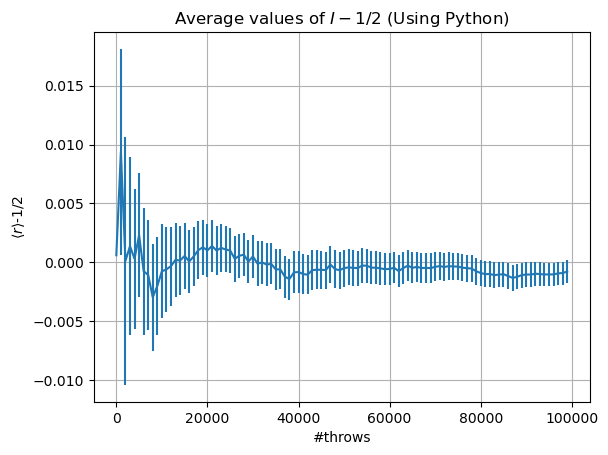

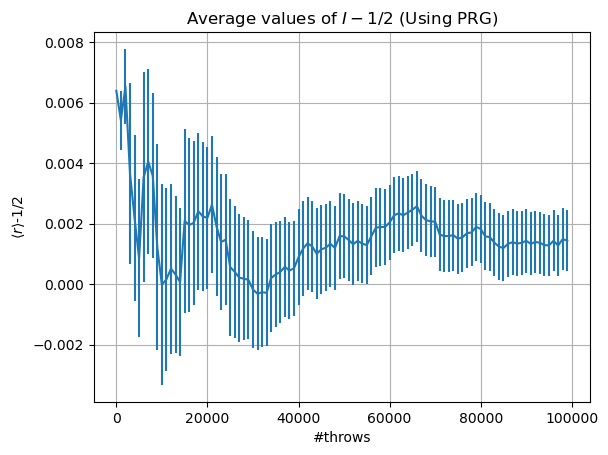

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
#from scipy.stats import cauchy, norm

# ============= GIVEN CODE ===========

def error(AV,AV2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((AV2[n] - AV[n]**2)/n)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block, please use for M a multiple of N
np.random.seed(1)     # Fixing random seed for reproducibility
r = np.random.rand(M) # U[0,1) uniform distribution
x = np.arange(N)      # [0,1,2,...,N-1]
ave = np.zeros(N)
av2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

for i in range(N):
    sum = 0
    for j in range(L):
        k = j+i*L
        sum += r[k]
    ave[i] = sum/L       # r_i 
    av2[i] = (ave[i])**2 # (r_i)^2 

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty
    
x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog-0.5,yerr=err_prog)
plt.title("Average values of $I-1/2$ (Using Python)")
plt.xlabel('#throws')
plt.ylabel(r'$\langle r \rangle $-1/2')
plt.grid(True)
plt.show()


# ------------- USING PRG (PARALLEL RANDOM GENERATOR) TO COMPUTE THE INTEGRAL ---------

file = open("./EX1_Parallel_Random_Generator/Monte_Carlo_output_files/MonteCarlo1_out.dat");

Lines = file.readlines()

N = len(Lines) # Number of blocks

x = np.arange(N)*L


avePRG, errPRG = np.loadtxt("./EX1_Parallel_Random_Generator/Monte_Carlo_output_files/MonteCarlo1_out.dat", usecols=(0,1), delimiter= " ", unpack="true")

plt.errorbar(x, avePRG -0.5, yerr=errPRG)
plt.title("Average values of $I-1/2$ (Using PRG)")
plt.xlabel('#throws')
plt.ylabel(r'$\langle r \rangle $-1/2')
plt.grid(True)
plt.show()

2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties).

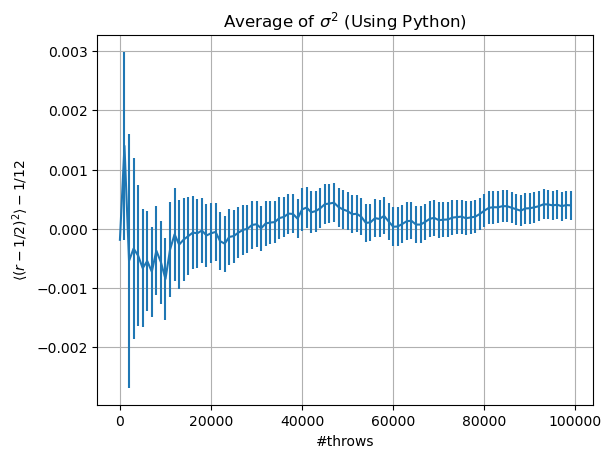

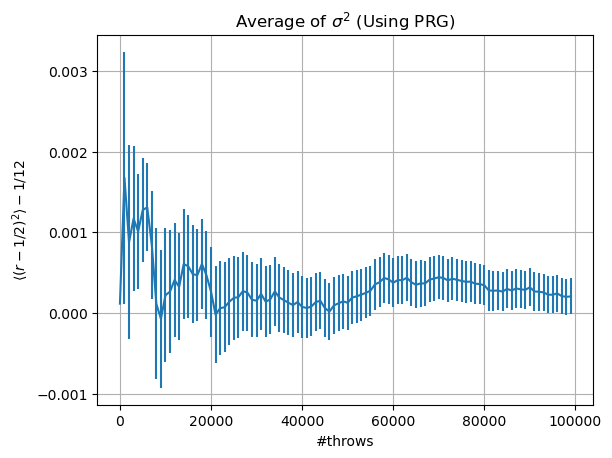

In [10]:
# ============= GIVEN CODE ===========

# Continue using variables and functions of the previous code cell
ave = np.zeros(N)
av2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

for i in range(N):
    sum = 0
    for j in range(L):
        k = j+i*L
        sum += (r[k]-0.5)**2 # Accumulate measures
    ave[i] = sum/L           # Estimate in each block 
    av2[i] = (ave[i])**2 

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] 
        su2_prog[i] += av2[j] 
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty
    
plt.errorbar(x,sum_prog-1/12,yerr=err_prog)
plt.title(r"Average of $\sigma^{2}$ (Using Python)")
plt.xlabel('#throws')
plt.ylabel(r'$\langle (r-1/2)^2 \rangle-1/12 $')
plt.grid(True)
plt.show()


# ------------- USING PRG (PARALLEL RANDOM GENERATOR) TO COMPUTE THE INTEGRAL ---------

file2 = open("./EX1_Parallel_Random_Generator/Monte_Carlo_output_files/MonteCarlo2_out.dat");

Lines = file2.readlines()

N = len(Lines) # Number of blocks

x = np.arange(N)*L

aveSecondPRG, errSecondPRG = np.loadtxt("./EX1_Parallel_Random_Generator/Monte_Carlo_output_files/MonteCarlo2_out.dat", usecols=(0,1), delimiter= " ", unpack="true")

plt.errorbar(x, aveSecondPRG-1/12, yerr=errSecondPRG)
plt.title(r"Average of $\sigma^{2}$ (Using PRG)")
plt.xlabel('#throws')
plt.ylabel(r'$\langle (r-1/2)^2 \rangle-1/12 $')
plt.grid(True)
plt.show()

# The Chi-Squared $\chi^2$ Test #

The $\chi^2$ test allows us to compare two random distributions (usually an <em>Observed</em> and an <em>Expected</em> distribution) and determine whether the variation between them is due to random fluctuation or not. For example if we flip 100 coins we can expect to get 50 heads and 50 tails. Does getting 48 heads and 52 tails results from statistical fluctuation or are the coins heavier on one side? Mathematically, we compute:

$$
\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
$$
<br>

Where $O_i$ is an observed value and $E_i$ is an expected value.

## Using the $\chi^2$ Test to check the quality of the PRNG ##

The **purpose of the $\chi^2$ test** in our case is to **check whether or not the numbers generated by the PRNG are in fact uniformly distributed**. To do so, we proceed in the following way:

1. Divide the interval $[0,1]$ in $M=$ equal sub-intervals:
2. Generate a batch of random numbers
3. Compare what we <em>observe</em> to what we <em>expect</em>
4. Repeat for 100 times

Proceeding this way we **expect the same ammount of random values** to fall into each sub-interval. In fact, with $M=10^2$ sub-intervals and $N=10^4$ realizations, each sub-interval should contain approximately $N/M = 100$ numbers.

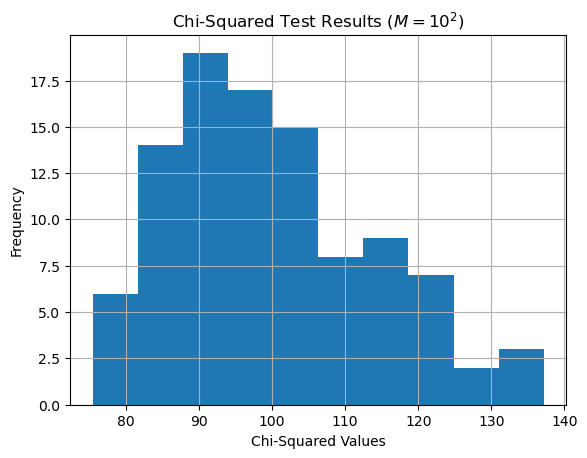

In [11]:
chiSquaredTest = np.loadtxt("./EX1_Parallel_Random_Generator/Chi_Squared_output_files/chi_squared.dat", usecols=0, delimiter=" ", unpack="true")

plt.hist(chiSquaredTest)
plt.grid(True)

plt.title(r'Chi-Squared Test Results $(M=10^2)$')
plt.xlabel("Chi-Squared Values")
plt.ylabel("Frequency")

plt.show()

###  Exercise 01.2
- Extend Pseudo-Random Number generator downloaded from the NSL Ariel web site and check the Central Limit Theorem:

1. <font color="red">Add two probability distributions</font> by using the **method of the inversion of the cumulative distribution** to sample from a **generic** <font color="red">exponential distribution</font>, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Exponential_distribution">this Wikipedia link</a>), and a **generic** <font color="red">Cauchy-Lorentz distribution</font> $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">this Wikipedia link</a>).
2. <font color="red">Make 3 pictures</font> with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).

Note that you can try to fit the case $N=100$ with a Gaussian for standard and exponential dices, whereas you should use a Cauchy-Lorentz distribution for the last case.

## EX.1.2 Checking The Central Limit Theorem ##
----------

### The Central Limit Theorem (Edit) ###

The central limit theorem states that if we take independent random samples of size $n$ from any population with finite mean and variance, then as $n$ becomes large, the distribution of the sample mean approaches a normal distribution, regardless of the shape of the original population.

Intuitively this can be translated as "averages of many small random influences behave normally, even when the influences themselves don’t".

### Method of the inversion of the cumulative distribution

The idea behind the method of the inversion of the cumulative distribution is to generate a probability distribution from a well-known probability distribution (such as the uniform distribution).

In our case, we are already able to generate a uniform distribution such as any $u\in[0,1]$ is uniformely distributed between 0 and 1 thanks to the <em>Pseudo Random Generator</em>.

The $\textit{Cumulative Distribution Function}$ (CDF) tells us the probability that a random variable is less or greater than a given value. Mathematically, this translates as follow:

Let $X$ be a random variable. The probability $P(X\leq x)$ that a given value $x$ is greater than $X$ is:

$$ F(x)=P(X \leq x) = \int_{-\infty}^x f(t) dt $$

where:
- $F(x)$ is the cumulative distribution function
- $f(t)$ is the probability density function

To generate a random variable $x$ that follows an arbitrary probability distribution we sample a uniform random variable $u$ and solve for $u=F(x)$, where $F(x)$ is a given cumulative distribution function.

### - Exponential Distribution

Given the **exponential distribution function**  

$$
p(x) = \lambda \: e^{-\lambda x}, \quad x\in [0, + \infty]
$$  

its **_cumulative_ distribution function** is given by:  

$$
F_x(x) = \begin{cases}  
1 - e^{-\lambda x}, & \quad x \geq 0 \\  
0, & \quad x < 0  
\end{cases}
$$ 

To sample a random value \( x \) distributed according to \( p(x) \), we generate a _uniformly distributed_ random variable \( u \) and solve the following equation for \( x \):  

$$
\begin{align}
u &= F(x) \\
u &= 1 - e^{-\lambda x} \\
e^{-\lambda x} &= 1 - u \\
-\lambda x &= \ln(1 - u) \\
x &= -\frac{1}{\lambda} \ln(1 - u)
\end{align}
$$





### - Cauchy-Lorentz Distribution

Given the **Cauchy-Lorentz distribution function** 

$$p_{Lorentz}(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2} \: , \quad x\in [-\infty;+\infty]$$

its corresponding **_cumulative_ distribution function** is:

$$ F_x(x) = \frac{1}{\pi} \arctan\left( \frac{x - \mu}{\Gamma} \right) + \frac{1}{2} $$

And so to sample a random value $x$ distributed according to $p_{Lorentz}$, we generate a _uniformly distributed_ random variable $u$ and solve this equation for $x$:


$$\begin{align}
u &= \frac{1}{\pi} \arctan\left( \frac{x - \mu}{\Gamma} \right) + \frac{1}{2} \\  
\arctan\left( \frac{x - \mu}{\Gamma} \right) &= \pi \left( u - \frac{1}{2} \right) \\  
\frac{x - \mu}{\Gamma} &= \tan\left[ \pi \left( u - \frac{1}{2} \right) \right] \\  
x &= \mu + \Gamma \tan\left[ \pi \left( u - \frac{1}{2} \right) \right]
\end{align}$$


## Blocked Statistics ##

Also known as the "blocking method" or "blocked averaging" is a technique to reduce autocorrelation within a dataset, and to obtain better estimates of statistical properties such as the variance or mean values.

Why is this important?

- <u>In Monte Carlo Simulations</u>:

  The random values used in MC simulations are produced by a "pseudo-random" number generator. These values are actually a sequence of numbers generated by a deterministic algorithm. Being a sequence, these values are correlated. The blocking method ensures first the quality of the pseudo-random number generator, second that the variance better reflects the real-life dataset.

- <u>In Markov Chains and Random Walks</u>:

    "Breaks" the autocorreltation resulting from the dependent process of random walks and Markov chains.

## Uniform Distribution ##

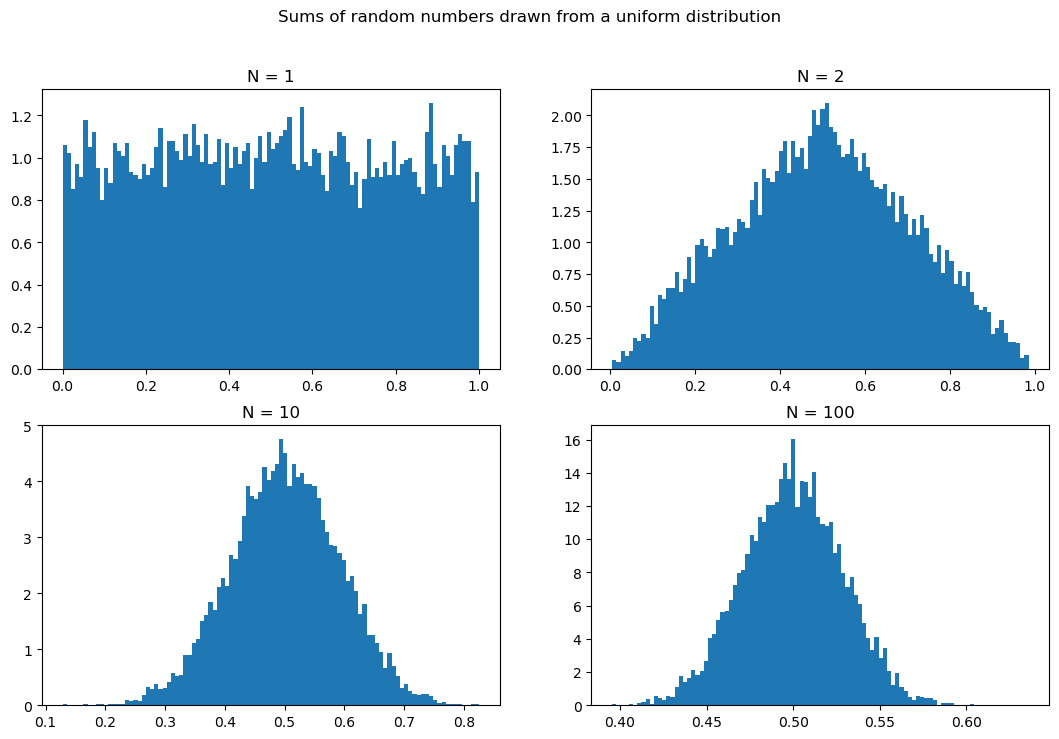

In [12]:
datafile = "./EX1_Parallel_Random_Generator/CLT_output_files/CLT_uniform_out.dat"

sums1, sums2, sums10, sums100 = np.loadtxt(datafile, usecols=(0, 1, 2, 3), delimiter=" ", unpack="true")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Sums of random numbers drawn from a uniform distribution")

axes[0, 0].hist(sums1, bins=100, density=True)
axes[0, 0].title.set_text("N = 1")
axes[0, 1].hist(sums2, bins=100, density=True)
axes[0, 1].title.set_text("N = 2")

axes[1, 0].hist(sums10, bins=100, density=True)
axes[1, 0].title.set_text("N = 10")
axes[1, 1].hist(sums100, bins=100, density=True)
axes[1, 1].title.set_text("N = 100")


# Generate x values
x = np.linspace(0.5, 1.5, 100)

plt.show()

## Exponential Distribution ##

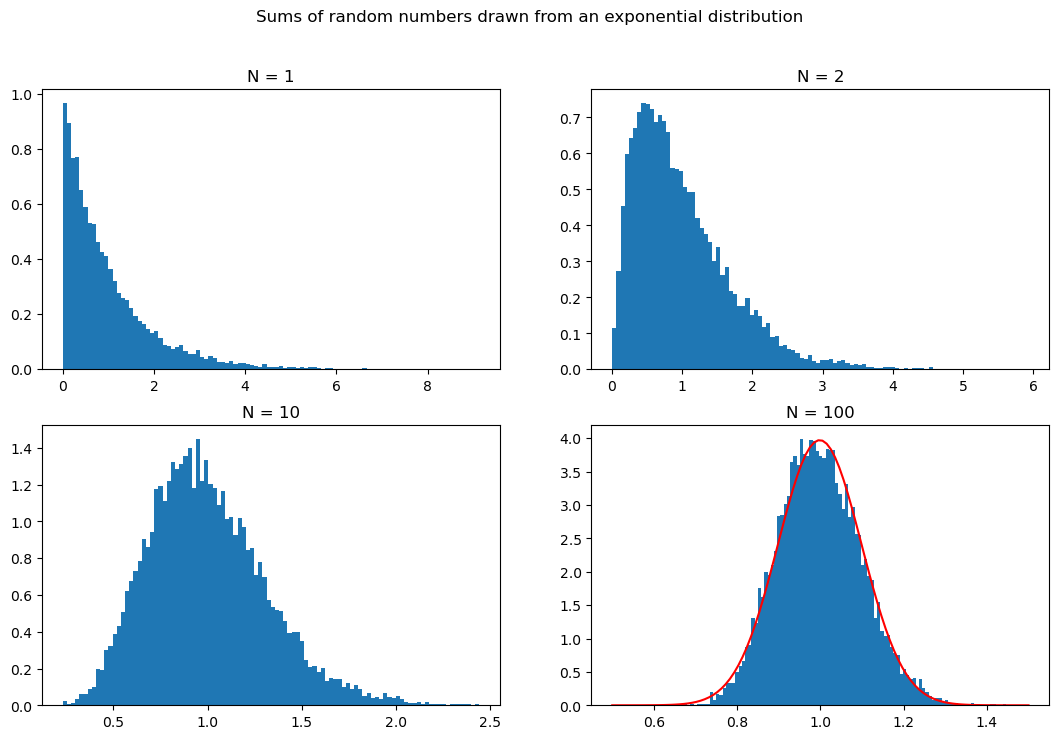

Fit : 0.9984976961999998 0.10045826512648477
Prediction : 1 0.1


In [13]:
datafile = "./EX1_Parallel_Random_Generator/CLT_output_files/CLT_exponential_out.dat"

sums1, sums2, sums10, sums100 = np.loadtxt(datafile, usecols=(0, 1, 2, 3), delimiter=" ", unpack="true")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Sums of random numbers drawn from an exponential distribution")

axes[0, 0].hist(sums1, bins=100, density=True)
axes[0, 0].title.set_text("N = 1")
axes[0, 1].hist(sums2, bins=100, density=True)
axes[0, 1].title.set_text("N = 2")

axes[1, 0].hist(sums10, bins=100, density=True)
axes[1, 0].title.set_text("N = 10")
axes[1, 1].hist(sums100, bins=100, density=True)
axes[1, 1].title.set_text("N = 100")

# Computing the mean and standard deviation to fit the histogram
mean = np.mean(sums100)
std_dev = np.std(sums100, ddof=0)  # Population std dev (ddof=0)

x = np.linspace(0.5, 1.5, 100)

# Applying Gaussian fit
gauss_fit = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

axes[1, 1].plot(x, gauss_fit, color="red")


plt.show()

print("Fit :", mean, std_dev)
print("Prediction :", 1, (1 / np.sqrt(100)))

## Cauchy-Lorentz Distribution ##

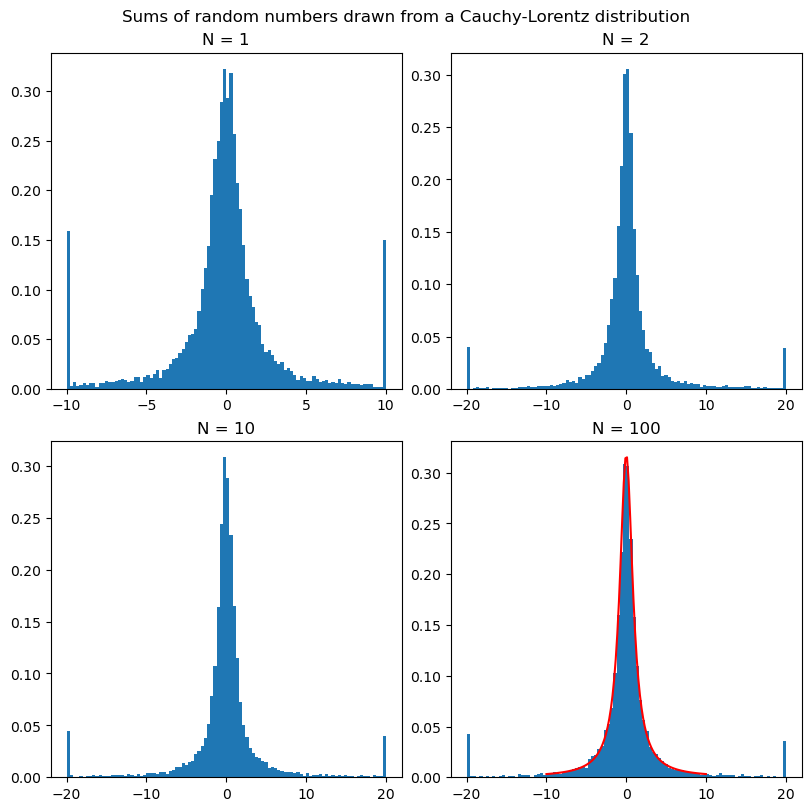

In [14]:
datafile = "./EX1_Parallel_Random_Generator/CLT_output_files/CLT_lorentzian_out.dat"

sums1, sums2, sums10, sums100 = np.loadtxt(datafile, usecols=(0, 1, 2, 3), delimiter=" ", unpack="true")

# Clipping the Cauchy-Lorentz in-between narrower values # (WRONG OPERATION ACTUALLY)
sums1 = np.clip(sums1, -10, 10)
sums2 = np.clip(sums2, -20, 20)
sums10 = np.clip(sums10, -20, 20)
sums100 = np.clip(sums100, -20, 20)

# Estimate Cauchy-Lorentz parameters manually
x0 = np.median(sums100)  # Peak location (median for Lorentzian)
gamma = (np.percentile(sums100, 75) - np.percentile(sums100, 25)) / 2  # Approximate scale

# Define Cauchy-Lorentz function
def lorentzian(x, x0, gamma):
    return (1 / np.pi) * (gamma / ((x - x0) ** 2 + gamma ** 2))

# Generate x values and compute fitted curve
x = np.linspace(min(sums100), max(sums100), 1000)
y = lorentzian(x, x0, gamma)

fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
fig.suptitle("Sums of random numbers drawn from a Cauchy-Lorentz distribution")

axes[0, 0].hist(sums1, bins=100, density=True)
axes[0, 0].title.set_text("N = 1")
axes[0, 1].hist(sums2, bins=100, density=True)
axes[0, 1].title.set_text("N = 2")

axes[1, 0].hist(sums10, bins=100, density=True)
axes[1, 0].title.set_text("N = 10")
axes[1, 1].hist(sums100, bins=100, density=True)
axes[1, 1].title.set_text("N = 100")

x = np.linspace(-10, 10, 100)
y = lorentzian(x, x0, gamma)

plt.plot(x, y, 'r-', label="Fitted Cauchy-Lorentz")
plt.show()

## Observations (Edited) ##
-------------

We can notice the spikes on each extremity of the plots. This is actually caused by the pyplot clipping operation. The spikes are not values from the true Lorentzian distribution. I mistakenly thought the clipping operation would simply "cut" the image to focus on the center of the distribution. Instead, the tail values accumulate to the clipping values, producing the spikes.

Regarding the central limit theorem, **the CLT does not apply to Lorentz distributions**. The distribution of averages of a Lorentzian distribution never approaches a Gaussian distribution. This is because its variance is infinite (if the plot is unclipped, the Lorentzian distribution would appear as a sharp spike), and the its expected value is undefined. Both these properties violates the conditions of the CLT. One way to show that the mean is undefined is by trying to compute:

$$
E[X] = \int_\infty^\infty x f(x) dx
$$

and notice that the integral diverges if $f(x)$ is the Lorentz distribution. The divergence of the variance can be shown similarly. Below I rewrote the previous code to correctly plot the distributions.

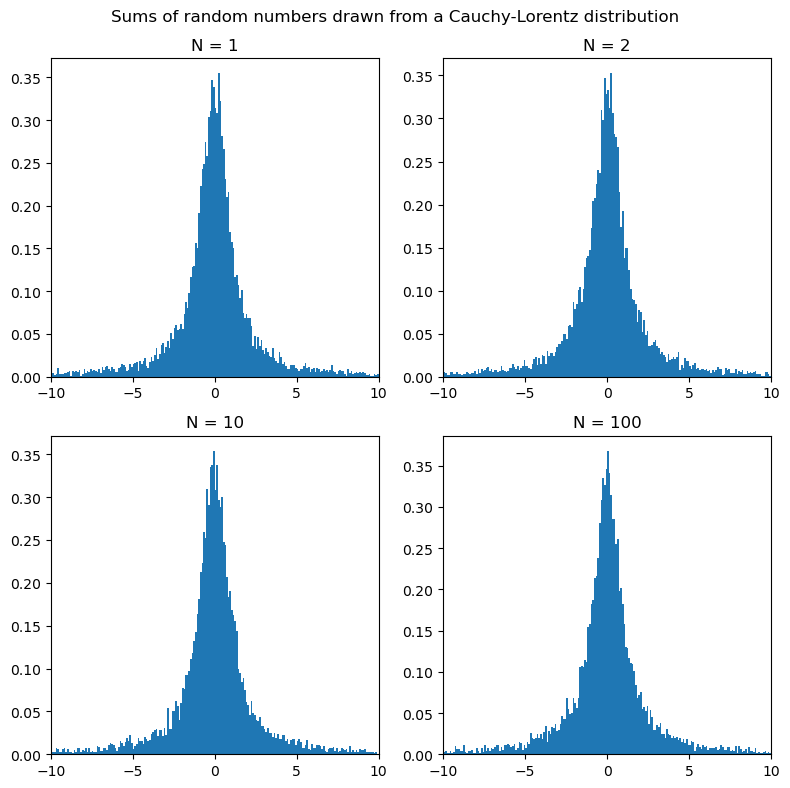

In [16]:
datafile = "./EX1_Parallel_Random_Generator/CLT_output_files/CLT_lorentzian_out.dat"

sums1, sums2, sums10, sums100 = np.loadtxt(datafile, usecols=(0, 1, 2, 3), delimiter=" ", unpack="true")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Sums of random numbers drawn from a Cauchy-Lorentz distribution")

datasets = [sums1, sums2, sums10, sums100]
titles = ["N = 1", "N = 2", "N = 10", "N = 100"]

for ax, data, title in zip(axes.ravel(), datasets, titles):
    ax.hist(data, bins=200, density=True, range=(-10, 10))  # RESTRICTING DATA
    ax.set_title(title)
    ax.set_xlim(-10, 10)  # FOCUSING ON BINS IN THE RANGE ±10

plt.tight_layout()
plt.show()

# Ex.1.3 Simulating the Buffon Experiment #
-------------

- **Simulate** the Buffon’s experiment (see LSN_Lecture_00, supplementary material):  A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ (must be $d > L$, but do not use $d\gg L$ otherwise $P\ll 1$) apart. The probability $P$ that the needle will intersect one of these lines is: $P = 2L/\pi d$. This could be used to evaluate $\pi$ from throws of the needle: if the needle is thrown down $N_{thr}$ times and is observed to land on a line $N_{hit}$ of those times, we can make an estimate of $\pi$ from
$$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$
<font color="red">Make a picture of the estimation of $\pi$ and its uncertainty (Standard Deviation of the mean) with a large number of *throws* $M$ as a function of the number of blocks, $N$</font> (see below: Computing statistical uncertainties). If possible, do not use $\pi$ to evaluate $\pi$.

## Defining the system ##

Let us proceed as follow. Consider the floor has a surface of 1 (a square of lenghts 1). We define the random coordinates $(x,y)\in [0,1]$ of the center of the needle as well as a random orientation angle $\theta \in [0,\pi]$. A needle has length $L=0.1$.

Imagine now that the floor has 10 lines (including the rim of the floor), each spaced by a distance $d=0.1$. The n-th line on the floor can be located by the coordinate $y_n$.

Now, to detect if a needle crosses a floor line we check if:

$$
y_n \in \left[ y_0- \frac{L}{2} sin\,\theta, \, y_0 + \frac{L}{2} sin\,\theta \right]
$$

Note: we don't strictly need the $x$ coordinate. However, the modeling is more intuitive if we imagine actual needles on a floor instead of projections onto an axis.

### Sampling $\theta$ ###

It is important to correctly sample a random angle $\theta$ **uniformly distributed** over $\in[0,2\pi)$. To do so, we will rely on the **accept-reject techique around the unit circle**. On can prove that the pobability of a point lying in an infinitesimal arc of angle $d\theta$ is proportional to $d\theta$, making this technique unbiased.

Estimate for $\pi$: 3.14152 +/- 0.0004 ( 0.0004 % )


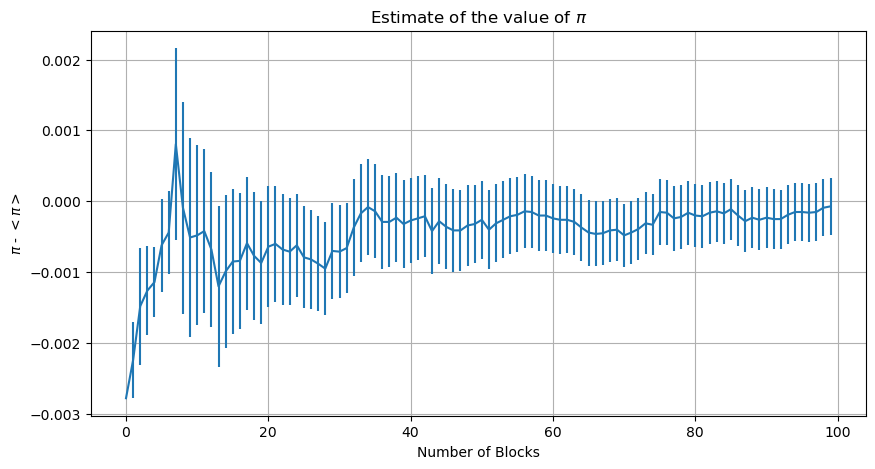

In [8]:
datafile = "./EX1_Parallel_Random_Generator/Buffon_output_files/Buffon_out.dat"
pi_estimate, error = np.loadtxt(datafile, usecols=(0, 2), delimiter=" ", unpack="true")

pi_estimate_result = pi_estimate[99]
pi_estimate_error = error[99]
pi_estimate_perror = round(pi_estimate_error / pi_estimate_result * 100, 6)
pi_estimate_error = round(error[99], 6)
print(r'Estimate for $\pi$:', pi_estimate_result, '+/-', pi_estimate_error, '(', pi_estimate_error, '% )')

x = np.arange(100)
plt.figure(figsize=(10, 5))
plt.errorbar(x, pi_estimate - np.pi, yerr=error)
plt.xlabel("Number of Blocks")
plt.ylabel(r'$\pi$ - $<\pi>$')
plt.title(r'Estimate of the value of $\pi$')
plt.grid(True)
plt.show()

### <span style="color:blue">Computing statistical uncertainties: the blocking method</span>
- A fundamental step in every Monte Carlo calculation is the estimation of its statistical uncertainty, **it's a must!** Your task would not be completed if you had not calculated it.

<p style="border:2px; border-style:solid; border-color:#F5F5F5; padding: 1em; background-color:#F5F5F5">
    In computing the statistical uncertainties, i.e. the standard deviation of the mean, you need an estimation of the variance $\sigma^2$, the second central moment. First of all note that the variance can be computed from
    $$\sigma^2_A := \langle (A-\langle A\rangle)^2\rangle = \langle A^2 \rangle -\langle A\rangle^2 $$
    What is the best way to estimate $\sigma^2_A$? Imagine that your Monte Carlo estimation of $A$ is obtained from a calculation which uses $M$ Monte Carlo "steps" (intentionally, here I am generic because what is a single "step" in a Monte Carlo calculation strictly depends on the specific calculation); you can always divide such $M$ Monte Carlo "steps" in $N$ blocks, with $N<M$. In each block, you can use your $M/N$ Monte Carlo "steps" to obtain an estimate of $A$, let me call it $A_i$ with $i=1,N$, and then you have also $A^2_i$ with $i=1,N$.
    At this point everything becomes clear:
    $$ \langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 $$
    and finally the statistical uncertainty with $N$ :
    $$\frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$
</p>

- <font color="blue">In a Monte Carlo calculation, you can use the arguments above to outputting an estimate of A and its statistical uncertainty on the fly, during your calculation. You will be able to do this every $M/N$ steps, and thus, in the end, $N$ times</font>. Note that after the first $M/N$ Monte Carlo steps, at the end of the first block, your estimation of the uncertainty is not computable, so set it to zero and compute it only from the second block. **Question**: $N$ can be chosen in many ways ... what are the limitations regarding this choice?